In [ ]:
!pip install kaggle xgboost scikit-learn pandas numpy matplotlib seaborn joblib imbalanced-learn pyarrow

In [ ]:
from google.colab import files

files.upload()   #it will prompt to upload a file

!mkdir -p ~/.kaggle #p is to create no error if folder already exists, its a hidden folder
!ls -l -a ~ #-la command don't work, so split it and write -l -a in colab

!cp /content/kaggle.json ~/.kaggle/ #the kaggle CLI looks for the json file in .kaggle folder

!ls -l -a ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json #giving read and write permission to just the user, READ:4, WRITE:2, EXECUTE:1, so 4+2=6, and no permissions for groups and other users

!ls -l -a ~/.kaggle/

!kaggle datasets download -d dhoogla/cicids2017 --unzip -p ./cicids2017 #download the dataset from kaggle.com/datasets/dhoogla/cicids2017 and copy it into a folder named cicids2017, in the current directory which is /content/

!ls -l -a /content/cicids2017/

Saving kaggle.json to kaggle.json
total 76
drwx------ 1 root root 4096 Jun  2 21:06 .
drwxr-xr-x 1 root root 4096 Jun  2 20:31 ..
-r-xr-xr-x 1 root root 1071 Jan  1  2000 .bashrc
drwxr-xr-x 1 root root 4096 May 26 13:33 .cache
drwxr-xr-x 1 root root 4096 May 26 13:33 .config
drwxr-xr-x 5 root root 4096 May 26 13:32 .ipython
drwxr-xr-x 1 root root 4096 May 26 13:15 .julia
drwx------ 1 root root 4096 May 26 13:33 .jupyter
drwxr-xr-x 2 root root 4096 Jun  2 21:06 .kaggle
drwxr-xr-x 2 root root 4096 Jun  2 20:31 .keras
drwx------ 3 root root 4096 May 18 13:08 .launchpadlib
drwxr-xr-x 1 root root 4096 May 26 13:15 .local
drwxr-xr-x 4 root root 4096 May 26 13:33 .npm
-rw-r--r-- 1 root root  161 Jul  9  2019 .profile
-r-xr-xr-x 1 root root  254 Jan  1  2000 .tmux.conf
-rw-r--r-- 1 root root  211 May 26 13:33 .wget-hsts
total 16
drwxr-xr-x 2 root root 4096 Jun  2 21:06 .
drwx------ 1 root root 4096 Jun  2 21:06 ..
-rw-r--r-- 1 root root   68 Jun  2 21:06 kaggle.json
total 16
drwxr-xr-x 2 root 

In [ ]:
import pandas as pd
import glob

In [ ]:
df_monday = pd.read_parquet('/content/cicids2017/Benign-Monday-no-metadata.parquet')
df_tuesday_bruteforce = pd.read_parquet('/content/cicids2017/Bruteforce-Tuesday-no-metadata.parquet')
df_wednesday_DOS = pd.read_parquet('/content/cicids2017/DoS-Wednesday-no-metadata.parquet')
df_thursday_web = pd.read_parquet('/content/cicids2017/WebAttacks-Thursday-no-metadata.parquet')
df_friday_botnet = pd.read_parquet('/content/cicids2017/Botnet-Friday-no-metadata.parquet')
df_friday_ddos = pd.read_parquet('/content/cicids2017/DDoS-Friday-no-metadata.parquet')
df_friday_portscan = pd.read_parquet('/content/cicids2017/Portscan-Friday-no-metadata.parquet')

display(df_monday.head()) #print function won't work properly
display(df_friday_botnet.head())

print("monday benigns shape: ", df_monday.shape)
print("tuesday bruteforce shape: ", df_tuesday_bruteforce.shape)
print("wednesday DOS shape: ", df_wednesday_DOS.shape)
print("thursday WEB ATTACKS shape: ", df_thursday_web.shape)
print("friday BOTNET shape: ", df_friday_botnet.shape)
print("friday DDOS shape: ", df_friday_ddos.shape)
print("friday Portscan shape: ", df_friday_portscan.shape)

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,4,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,6,3,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,6,609,7,4,484,414,233,0,69.14286,111.967896,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,112740690,32,16,6448,1152,403,0,201.5,204.724197,...,32,3.594286e+02,1.199802e+01,380,343,16100000.0,4.988048e+05,16400000,15400000,Benign
1,6,112740560,32,16,6448,5056,403,0,201.5,204.724197,...,32,3.202857e+02,1.574499e+01,330,285,16100000.0,4.987937e+05,16400000,15400000,Benign
2,0,113757377,545,0,0,0,0,0,0.0,0.000000,...,0,9.361829e+06,7.324646e+06,18900000,19,12200000.0,6.935824e+06,20800000,5504997,Benign
3,17,100126,22,0,616,0,28,28,28.0,0.000000,...,32,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,Benign
4,0,54760,4,0,0,0,0,0,0.0,0.000000,...,0,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,Benign


monday benigns shape:  (458831, 78)
tuesday bruteforce shape:  (389714, 78)
wednesday DOS shape:  (584991, 78)
thursday WEB ATTACKS shape:  (155820, 78)
friday BOTNET shape:  (176038, 78)
friday DDOS shape:  (221264, 78)
friday Portscan shape:  (119522, 78)


In [ ]:
display("MONDAY", df_monday.groupby(df_monday["Label"]).count(),
"TUESDAY", df_tuesday_bruteforce.groupby(df_tuesday_bruteforce["Label"]).count(),
"WEDNESDAY", df_wednesday_DOS.groupby(df_wednesday_DOS["Label"]).count(),
"THURSDAY", df_thursday_web.groupby(df_thursday_web["Label"]).count(),
"FRIDAY BOT", df_friday_botnet.groupby(df_friday_botnet["Label"]).count(),
"FRIDAY DDoS", df_friday_ddos.groupby(df_friday_ddos["Label"]).count(),
"FRIDAY Portscan", df_friday_portscan.groupby(df_friday_portscan["Label"]).count())

/tmp/ipykernel_8323/2029480271.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display("MONDAY", df_monday.groupby(df_monday["Label"]).count(),
/tmp/ipykernel_8323/2029480271.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  "TUESDAY", df_tuesday_bruteforce.groupby(df_tuesday_bruteforce["Label"]).count(),
/tmp/ipykernel_8323/2029480271.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  "WEDNESDAY", df_wednesday_DO

'MONDAY'

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Act Data Packets,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
Label,,,,,,,,,,,,,,,,,,,,,
Benign,458831,458831,458831,458831,458831,458831,458831,458831,458831,458831,...,458831,458831,458831,458831,458831,458831,458831,458831,458831,458831


'TUESDAY'

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Act Data Packets,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
Label,,,,,,,,,,,,,,,,,,,,,
Benign,380564,380564,380564,380564,380564,380564,380564,380564,380564,380564,...,380564,380564,380564,380564,380564,380564,380564,380564,380564,380564
FTP-Patator,5931,5931,5931,5931,5931,5931,5931,5931,5931,5931,...,5931,5931,5931,5931,5931,5931,5931,5931,5931,5931
SSH-Patator,3219,3219,3219,3219,3219,3219,3219,3219,3219,3219,...,3219,3219,3219,3219,3219,3219,3219,3219,3219,3219


...

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Act Data Packets,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
Label,,,,,,,,,,,,,,,,,,,,,
Benign,174601,174601,174601,174601,174601,174601,174601,174601,174601,174601,...,174601,174601,174601,174601,174601,174601,174601,174601,174601,174601
Bot,1437,1437,1437,1437,1437,1437,1437,1437,1437,1437,...,1437,1437,1437,1437,1437,1437,1437,1437,1437,1437


'FRIDAY DDoS'

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Act Data Packets,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
Label,,,,,,,,,,,,,,,,,,,,,
Benign,93250,93250,93250,93250,93250,93250,93250,93250,93250,93250,...,93250,93250,93250,93250,93250,93250,93250,93250,93250,93250
DDoS,128014,128014,128014,128014,128014,128014,128014,128014,128014,128014,...,128014,128014,128014,128014,128014,128014,128014,128014,128014,128014


'FRIDAY Portscan'

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Act Data Packets,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
Label,,,,,,,,,,,,,,,,,,,,,
Benign,117566,117566,117566,117566,117566,117566,117566,117566,117566,117566,...,117566,117566,117566,117566,117566,117566,117566,117566,117566,117566
PortScan,1956,1956,1956,1956,1956,1956,1956,1956,1956,1956,...,1956,1956,1956,1956,1956,1956,1956,1956,1956,1956


In [ ]:
#cell 2

import pandas as pd
import numpy as np
import joblib, glob, warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [ ]:
#Cell 3: Load

all_files = glob.glob('./cicids2017/*.parquet')  #glob is a Python module used to find files matching a pattern

# print(type(all_files))
# print(all_files)

df_list = [pd.read_parquet(f) for f in all_files]
df = pd.concat(df_list, ignore_index=True) #ignore_index=True so that the original index numbering get replaced with new numbering as 0,1,2,3,...

print(f"Raw shape: {df.shape}") #can also be written as print("Raw shape: ", df.shape)
print(f"Columns: {df.columns.tolist()}")

Raw shape: (2313810, 78)
Columns: ['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Cou

In [ ]:
import numpy as np

In [ ]:
#Cell 4: Clean

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
print(f"After cleaning: {df.shape}")
print(df['Label'].value_counts())

After cleaning: (2313810, 78)
Label
Benign                        1977318
DoS Hulk                       172846
DDoS                           128014
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
PortScan                         1956
Web Attack � Brute Force         1470
Bot                              1437
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [ ]:
df['label_binary'] = df['Label'].apply(lambda x: 0 if x == 'Benign' else 1)
display(df['label_binary'].value_counts())

,count
label_binary,
0,1977318
1,336492


In [ ]:
#Cell 6: Use ALL features

# Drop only non-feature columns
drop_cols = ['Label', 'label_binary']

#INPUT
X = df.drop(drop_cols, axis=1) #drop the column(axis=1) with names in drop_cols

#TARGET
y = df['label_binary']

# Keep only numeric
X = X.select_dtypes(include=[np.number]) #nothing important gets removed because every remaining feature is already numeric, or we could have just used one hot encoding, you can check by seeing the output of df.select_dtypes(exclude=[np.number]).columns

# Clip negatives to 0
X = X.clip(lower=0) #Any negative value becomes 0

In [ ]:
from matplotlib import pyplot as plt

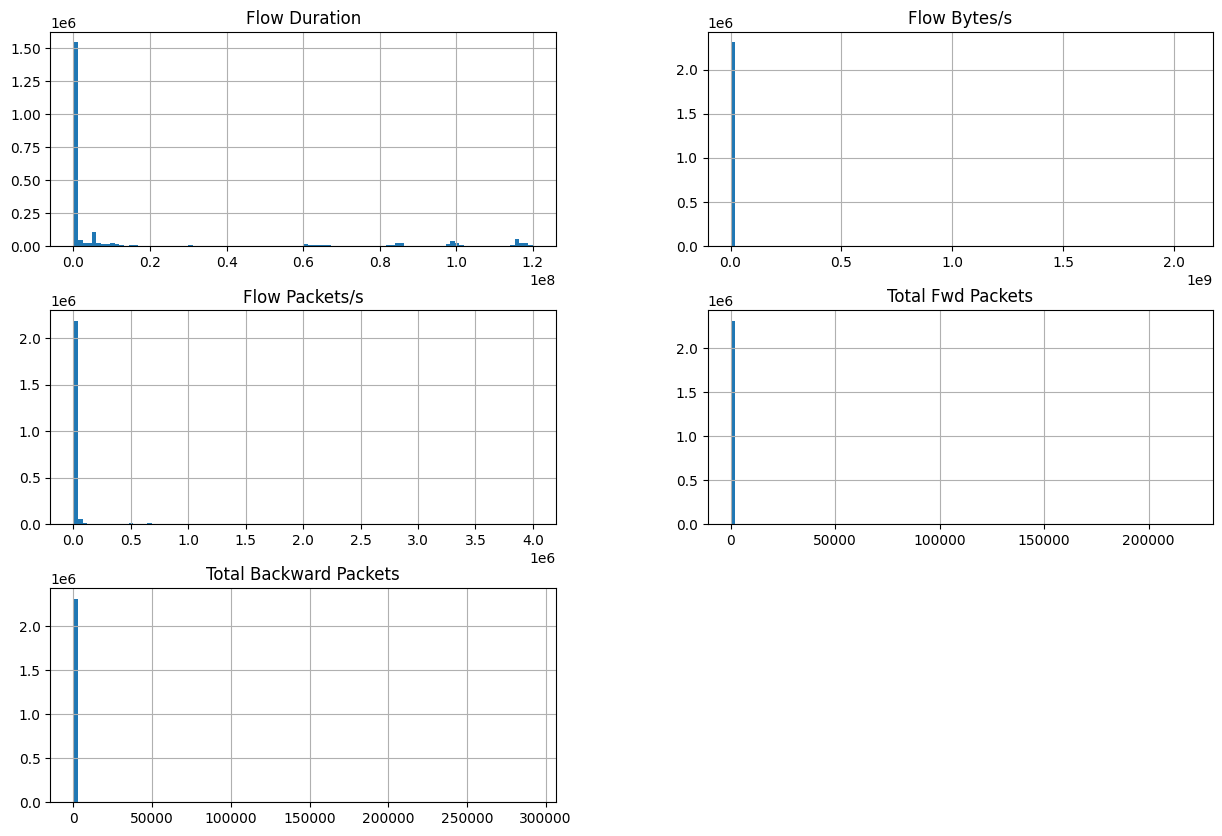

In [ ]:
X[['Flow Duration',
   'Flow Bytes/s',
   'Flow Packets/s',
   'Total Fwd Packets',
   'Total Backward Packets']].hist(
       bins=100,
       figsize=(15,10)
)
plt.show()

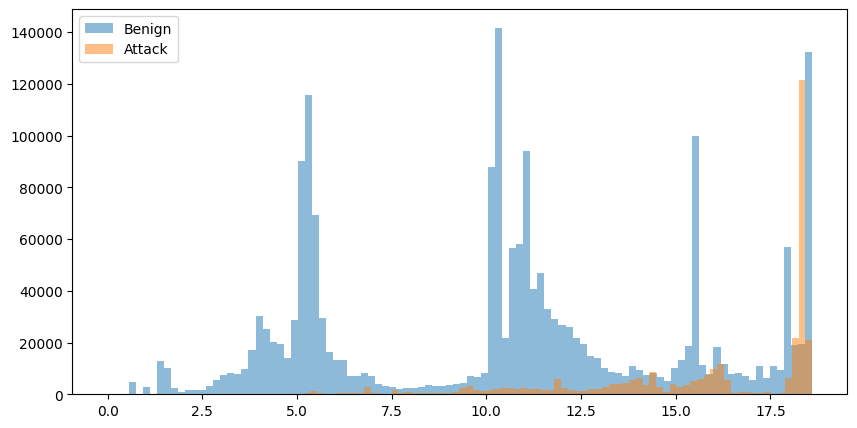

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    np.log1p(X[y==0]['Flow Duration']),
    bins=100,
    alpha=0.5,
    label='Benign'
)

plt.hist(
    np.log1p(X[y==1]['Flow Duration']),
    bins=100,
    alpha=0.5,
    label='Attack'
)

plt.legend()
plt.show()

In [ ]:
keep_mask = pd.Series([True] * len(X), index=X.index)

for col in X.columns:
    q1 = X[col].quantile(0.01)
    q99 = X[col].quantile(0.99)
    keep_mask &= (X[col] >= q1) & (X[col] <= q99)

print("Original rows:", len(X))
print("Rows kept:", keep_mask.sum())
print("Rows removed:", len(X) - keep_mask.sum())
print("Percent removed:", 100*(len(X)-keep_mask.sum())/len(X))

Original rows: 2313810
Rows kept: 1923936
Rows removed: 389874
Percent removed: 16.84987099200021


In [ ]:
# Remove outliers (1st-99th percentile)
keep_mask = pd.Series([True] * len(X), index=X.index)
for col in X.columns:
    q1  = X[col].quantile(0.01)
    q99 = X[col].quantile(0.99)
    keep_mask = keep_mask & (X[col] >= q1) & (X[col] <= q99)

X = X[keep_mask]
y = y[keep_mask]

feature_cols = list(X.columns)
print(f"✅ Total features: {len(feature_cols)}")
print(feature_cols)

✅ Total features: 77
['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Fla

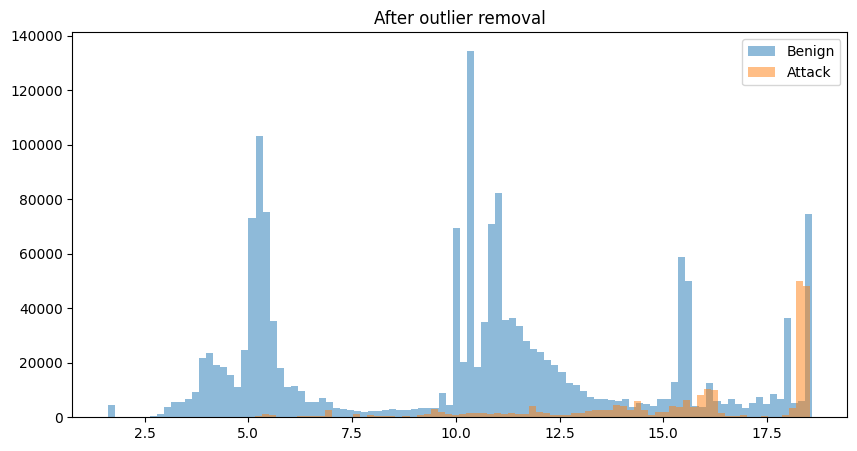

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    np.log1p(X[y==0]['Flow Duration']),
    bins=100,
    alpha=0.5,
    label='Benign'
)

plt.hist(
    np.log1p(X[y==1]['Flow Duration']),
    bins=100,
    alpha=0.5,
    label='Attack'
)

plt.title("After outlier removal")

plt.legend()
plt.show()

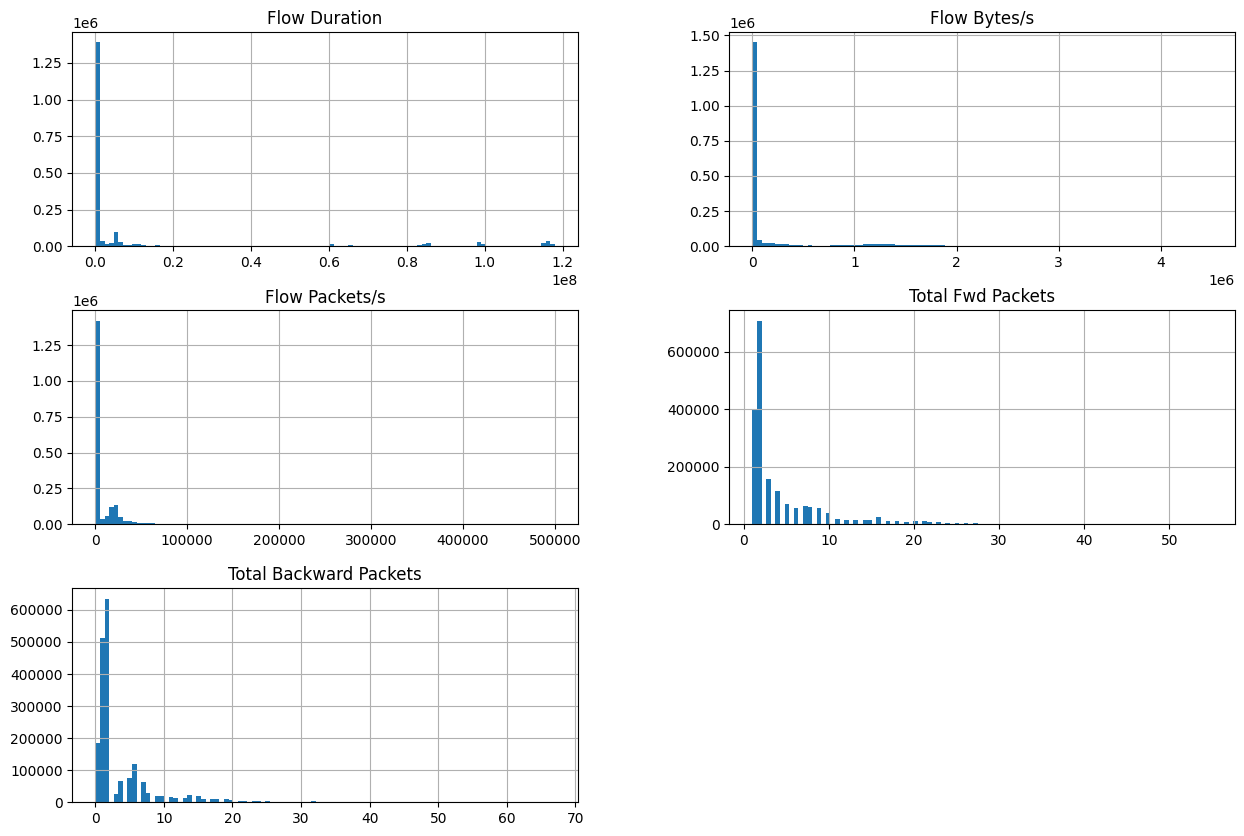

In [ ]:
X[['Flow Duration',
   'Flow Bytes/s',
   'Flow Packets/s',
   'Total Fwd Packets',
   'Total Backward Packets']].hist(
       bins=100,
       figsize=(15,10)
)
plt.show()

In [ ]:
# Print ALL values without truncation
pd.set_option('display.max_rows', 100)

print("=== ATTACK mean values ===")
attack_means = X[y==1].mean()
for col, val in attack_means.items():
    print(f'  "{col}": {val:.4f},')

print("\n=== BENIGN mean values ===")
benign_means = X[y==0].mean()
for col, val in benign_means.items():
    print(f'  "{col}": {val:.4f},')

=== ATTACK mean values ===
  "Protocol": 6.0000,
  "Flow Duration": 41190673.1391,
  "Total Fwd Packets": 5.6408,
  "Total Backward Packets": 4.7597,
  "Fwd Packets Length Total": 245.0043,
  "Bwd Packets Length Total": 7706.8162,
  "Fwd Packet Length Max": 187.5764,
  "Fwd Packet Length Min": 1.3840,
  "Fwd Packet Length Mean": 36.2260,
  "Fwd Packet Length Std": 74.4713,
  "Bwd Packet Length Max": 3821.5878,
  "Bwd Packet Length Min": 0.0398,
  "Bwd Packet Length Mean": 1297.6381,
  "Bwd Packet Length Std": 1589.0236,
  "Flow Bytes/s": 29282.6816,
  "Flow Packets/s": 648.7234,
  "Flow IAT Mean": 3617874.5000,
  "Flow IAT Std": 11931163.0000,
  "Flow IAT Max": 40708320.2903,
  "Flow IAT Min": 423.6805,
  "Fwd IAT Total": 40815952.2806,
  "Fwd IAT Mean": 6959552.5000,
  "Fwd IAT Std": 16569371.0000,
  "Fwd IAT Max": 40569379.3090,
  "Fwd IAT Min": 57246.1639,
  "Bwd IAT Total": 8998457.0646,
  "Bwd IAT Mean": 1540479.2500,
  "Bwd IAT Std": 3530021.2500,
  "Bwd IAT Max": 8645176.2062,
 

In [ ]:
# Build the exact curl test payload from attack means
import json

attack_dict = {col: round(float(val), 4) for col, val in attack_means.items()}
print("\n=== CURL TEST PAYLOAD ===")
print(json.dumps({"features": attack_dict}, indent=2))


=== CURL TEST PAYLOAD ===
{
  "features": {
    "Protocol": 6.0,
    "Flow Duration": 41190673.1391,
    "Total Fwd Packets": 5.6408,
    "Total Backward Packets": 4.7597,
    "Fwd Packets Length Total": 245.0043,
    "Bwd Packets Length Total": 7706.8162,
    "Fwd Packet Length Max": 187.5764,
    "Fwd Packet Length Min": 1.384,
    "Fwd Packet Length Mean": 36.226,
    "Fwd Packet Length Std": 74.4713,
    "Bwd Packet Length Max": 3821.5878,
    "Bwd Packet Length Min": 0.0398,
    "Bwd Packet Length Mean": 1297.6381,
    "Bwd Packet Length Std": 1589.0236,
    "Flow Bytes/s": 29282.6816,
    "Flow Packets/s": 648.7234,
    "Flow IAT Mean": 3617874.5,
    "Flow IAT Std": 11931163.0,
    "Flow IAT Max": 40708320.2903,
    "Flow IAT Min": 423.6805,
    "Fwd IAT Total": 40815952.2806,
    "Fwd IAT Mean": 6959552.5,
    "Fwd IAT Std": 16569371.0,
    "Fwd IAT Max": 40569379.309,
    "Fwd IAT Min": 57246.1639,
    "Bwd IAT Total": 8998457.0646,
    "Bwd IAT Mean": 1540479.25,
    "Bwd IA

In [ ]:
#Cell 7: Split + SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Before SMOTE:\n{y_train.value_counts()}")

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"After SMOTE:\n{pd.Series(y_train_bal).value_counts()}")

Train: (1539148, 77) | Test: (384788, 77)
Before SMOTE:
label_binary
0    1348558
1     190590
Name: count, dtype: int64
Train: (1539148, 77) | Test: (384788, 77)
After SMOTE:
label_binary
0    1348558
1    1348558
Name: count, dtype: int64


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p /content/drive/MyDrive/ids_cache

In [ ]:
(
 X_train,
 X_test,
 y_train,
 y_test,
 X_train_bal,
 y_train_bal
) = joblib.load(
    '/content/drive/MyDrive/ids_cache/smote_data.pkl'
)

In [ ]:
attack_types = df['Label'].unique()
key_features = [
    'Flow Duration', 'Flow Bytes/s', 'Flow Packets/s',
    'Idle Mean', 'Bwd Packet Length Mean', 'Avg Bwd Segment Size',
    'Total Fwd Packets', 'SYN Flag Count', 'RST Flag Count',
    'FIN Flag Count', 'PSH Flag Count', 'ACK Flag Count',
    'Fwd Packet Length Mean', 'Packet Length Mean',
    'Init Fwd Win Bytes', 'Init Bwd Win Bytes',
    'Fwd Packets/s', 'Bwd Packets/s'
]

for label in sorted(attack_types):
    group = df[df['Label'] == label]
    print(f"\n{'='*50}")
    print(f"  {label}  (n={len(group)})")
    print(f"{'='*50}")
    for feat in key_features:
        if feat in group.columns:
            print(f"  {feat}:")
            print(f"    mean={group[feat].mean():.2f}  std={group[feat].std():.2f}  "
                  f"min={group[feat].min():.2f}  max={group[feat].max():.2f}")


  Benign  (n=1977318)
  Flow Duration:
    mean=12884191.24  std=31953015.14  min=-13.00  max=119999998.00
  Flow Bytes/s:
    mean=570250.74  std=8542093.74  min=-261000000.00  max=2071000000.00
  Flow Packets/s:
    mean=23683.76  std=133536.74  min=-2000000.00  max=4000000.00
  Idle Mean:
    mean=4304978.50  std=14546376.00  min=0.00  max=120000000.00
  Bwd Packet Length Mean:
    mean=182.80  std=297.25  min=0.00  max=3787.34
  Avg Bwd Segment Size:
    mean=182.80  std=297.25  min=0.00  max=3787.34
  Total Fwd Packets:
    mean=11.96  std=896.92  min=1.00  max=219759.00
  SYN Flag Count:
    mean=0.04  std=0.20  min=0.00  max=1.00
  RST Flag Count:
    mean=0.00  std=0.02  min=0.00  max=1.00
  FIN Flag Count:
    mean=0.01  std=0.09  min=0.00  max=1.00
  PSH Flag Count:
    mean=0.27  std=0.44  min=0.00  max=1.00
  ACK Flag Count:
    mean=0.25  std=0.43  min=0.00  max=1.00
  Fwd Packet Length Mean:
    mean=73.83  std=216.58  min=0.00  max=4672.00
  Packet Length Mean:
    mean

In [ ]:
#Cell 8: Train

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    eval_metric='logloss',
    tree_method='hist',
    device='cuda',
    early_stopping_rounds=20, #20 rounds without improvement:STOP TRAINING, Prevents wasting time.
    subsample=0.8, #Each tree only sees: 80% of training rows, chosen randomly.Helps prevent overfitting
    colsample_bytree=0.8, #Each tree only sees: 80% of features, instead of all 77 features. Again helps prevent overfitting.
    random_state=42
)

xgb_model.fit(
    X_train_bal, y_train_bal,
    eval_set=[(X_test, y_test)],
    verbose=50
)
print("✅ Training complete!")

[0]	validation_0-logloss:0.64578
[50]	validation_0-logloss:0.04774
[100]	validation_0-logloss:0.00961
[150]	validation_0-logloss:0.00530
[200]	validation_0-logloss:0.00418
[250]	validation_0-logloss:0.00348
[299]	validation_0-logloss:0.00314
✅ Training complete!


Accuracy : 0.9988
F1 Score : 0.9953
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    337140
      Attack       0.99      1.00      1.00     47648

    accuracy                           1.00    384788
   macro avg       1.00      1.00      1.00    384788
weighted avg       1.00      1.00      1.00    384788



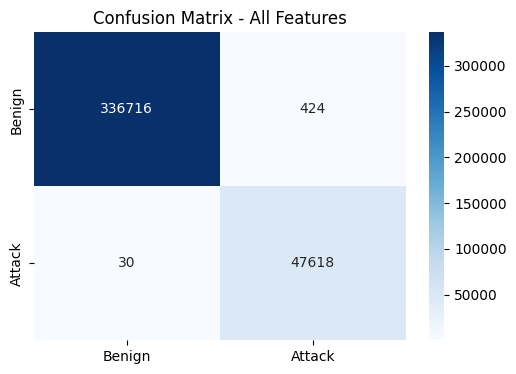

In [ ]:
#Cell 9: Evaluate

y_pred = xgb_model.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=['Benign','Attack']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign','Attack'],
            yticklabels=['Benign','Attack'])
plt.title('Confusion Matrix - All Features')
plt.show()

In [ ]:
#Cell 10: Check exact CICFlowMeter column names

# Print feature names exactly as they appear
# so live_ids.py COLUMN_MAP matches perfectly
print("Feature columns (copy these exactly):")
for i, col in enumerate(feature_cols):
    print(f"  {i+1}. '{col}'")


Feature columns (copy these exactly):
  1. 'Protocol'
  2. 'Flow Duration'
  3. 'Total Fwd Packets'
  4. 'Total Backward Packets'
  5. 'Fwd Packets Length Total'
  6. 'Bwd Packets Length Total'
  7. 'Fwd Packet Length Max'
  8. 'Fwd Packet Length Min'
  9. 'Fwd Packet Length Mean'
  10. 'Fwd Packet Length Std'
  11. 'Bwd Packet Length Max'
  12. 'Bwd Packet Length Min'
  13. 'Bwd Packet Length Mean'
  14. 'Bwd Packet Length Std'
  15. 'Flow Bytes/s'
  16. 'Flow Packets/s'
  17. 'Flow IAT Mean'
  18. 'Flow IAT Std'
  19. 'Flow IAT Max'
  20. 'Flow IAT Min'
  21. 'Fwd IAT Total'
  22. 'Fwd IAT Mean'
  23. 'Fwd IAT Std'
  24. 'Fwd IAT Max'
  25. 'Fwd IAT Min'
  26. 'Bwd IAT Total'
  27. 'Bwd IAT Mean'
  28. 'Bwd IAT Std'
  29. 'Bwd IAT Max'
  30. 'Bwd IAT Min'
  31. 'Fwd PSH Flags'
  32. 'Bwd PSH Flags'
  33. 'Fwd URG Flags'
  34. 'Bwd URG Flags'
  35. 'Fwd Header Length'
  36. 'Bwd Header Length'
  37. 'Fwd Packets/s'
  38. 'Bwd Packets/s'
  39. 'Packet Length Min'
  40. 'Packet Length M

In [ ]:
#Cell 11: Export

import os, shutil
os.makedirs('ids_model', exist_ok=True)

xgb_model.save_model('ids_model/xgb_model.json')
joblib.dump(feature_cols, 'ids_model/feature_cols.pkl')
df[['Label','label_binary']].drop_duplicates().to_csv('ids_model/label_map.csv', index=False)

from google.colab import drive
drive.mount('/content/drive')
os.makedirs('/content/drive/MyDrive/ids_model', exist_ok=True)
xgb_model.save_model('/content/drive/MyDrive/ids_model/xgb_model.json')
joblib.dump(feature_cols, '/content/drive/MyDrive/ids_model/feature_cols.pkl')
print("✅ Saved!")
print(f"Total features: {len(feature_cols)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Saved!
Total features: 77


In [ ]:
#Cell 12: Download

shutil.make_archive('ids_model', 'zip', 'ids_model')
files.download('ids_model.zip')